In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Train Dataset Shape: (428, 3)
Test Dataset Shape: (106, 3)


In [ ]:
TEXT_COLUMN = "Article"
LABEL_COLUMN = "Category"

In [ ]:


vectorizer = CountVectorizer(
    stop_words='english',
    max_features=5000
)

X_train = vectorizer.fit_transform(train_df[TEXT_COLUMN])
X_test = vectorizer.transform(test_df[TEXT_COLUMN])

feature_names = vectorizer.get_feature_names_out()


In [ ]:
print("\n===== Dataset Statistics =====")

print(f"Number of training articles: {X_train.shape[0]}")
print(f"Number of testing articles : {X_test.shape[0]}")

print(f"\nNumber of extracted features (train): {X_train.shape[1]}")
print(f"Number of extracted features (test) : {X_test.shape[1]}")


===== Dataset Statistics =====
Number of training articles: 428
Number of testing articles : 106

Number of extracted features (train): 5000
Number of extracted features (test) : 5000


In [ ]:
# Show 5 example articles with extracted features


example_indices = range(5)

example_features = []

for idx in example_indices:
    row = X_train[idx].toarray()[0]
    
    # Get non-zero features
    feature_dict = {
        feature_names[i]: int(row[i])
        for i in np.where(row > 0)[0]
    }
    
    example_features.append({
        "Article": train_df.iloc[idx][TEXT_COLUMN][:250] + "...",
        "Extracted Features": feature_dict
    })

example_df = pd.DataFrame(example_features)

print("\n===== 5 Example Articles with Extracted Features =====")
print(example_df)



===== 5 Example Articles with Extracted Features =====
                                             Article  \
0  lifestyle governs mobile choice faster better ...   
1  french honour director parker british film dir...   
2  fockers fuel festive film chart comedy meet fo...   
3  housewives lift channel 4 ratings debut us tel...   
4  u2 desire number one u2 three prestigious gram...   

                                  Extracted Features  
0  {'000': 1, '14': 2, '2003': 2, '25': 1, '29': ...  
1  {'2003': 1, 'alan': 3, 'artist': 1, 'artistic'...  
2  {'12': 3, '19': 1, '1m': 2, '2003': 1, '23': 1...  
3  {'11': 1, '12': 1, '20': 1, '2002': 1, '2004':...  
4  {'10': 1, '12': 1, '125': 1, '17': 1, '1978': ...  


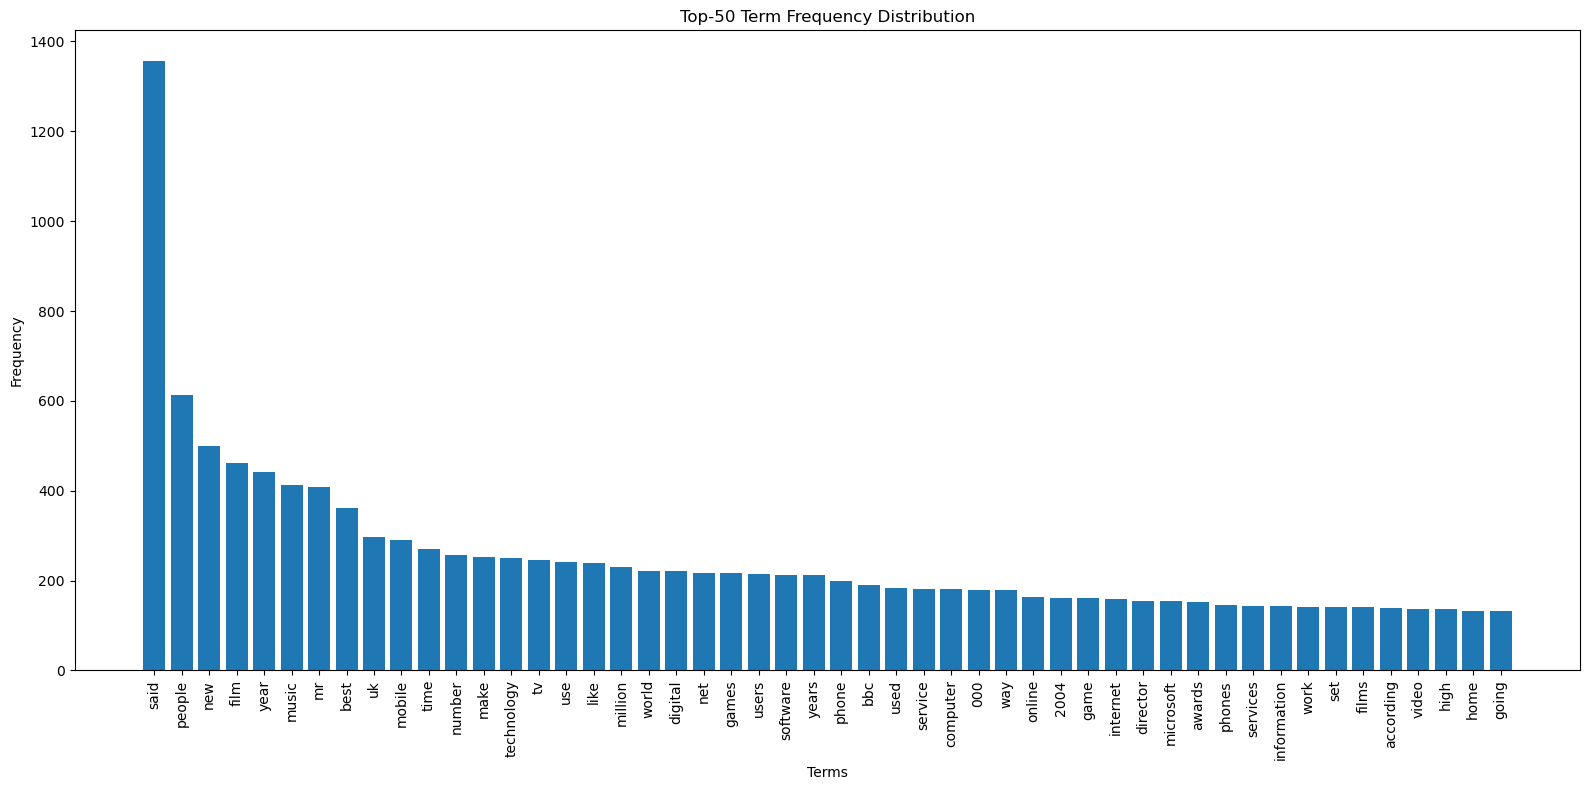

In [ ]:

# (b) Term Frequency Analysis

# (i) Top-50 Term Frequency Distribution

term_frequencies = np.array(X_train.sum(axis=0)).flatten()

term_freq_df = pd.DataFrame({
    'term': feature_names,
    'frequency': term_frequencies
})

top50 = term_freq_df.sort_values(
    by='frequency',
    ascending=False
).head(50)

plt.figure(figsize=(16, 8))
plt.bar(top50['term'], top50['frequency'])
plt.xticks(rotation=90)
plt.title("Top-50 Term Frequency Distribution")
plt.xlabel("Terms")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


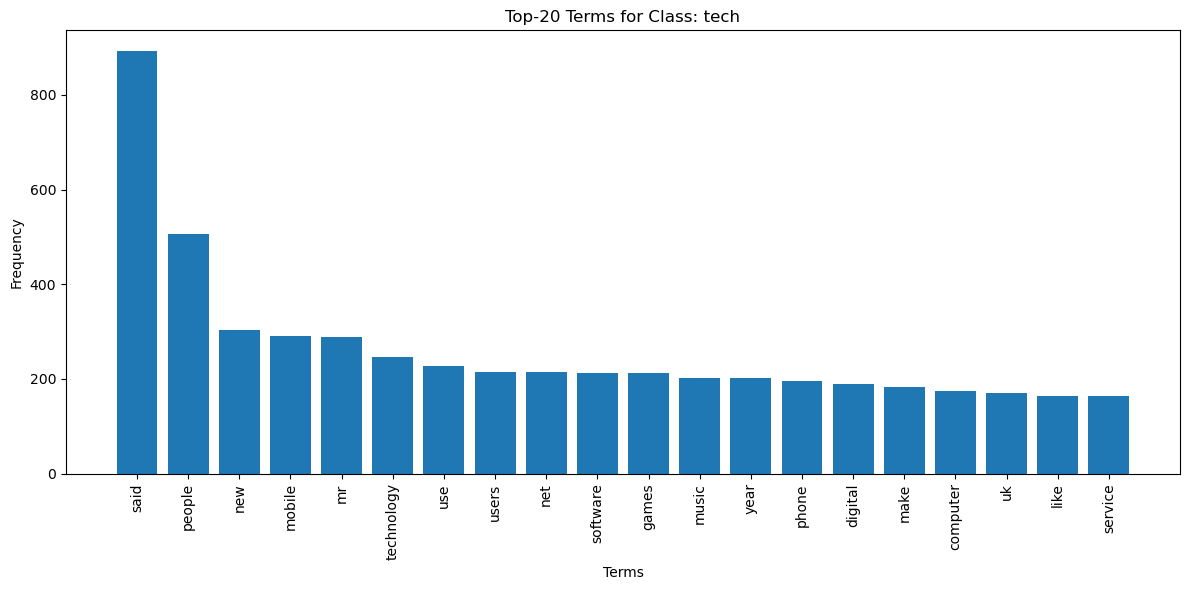

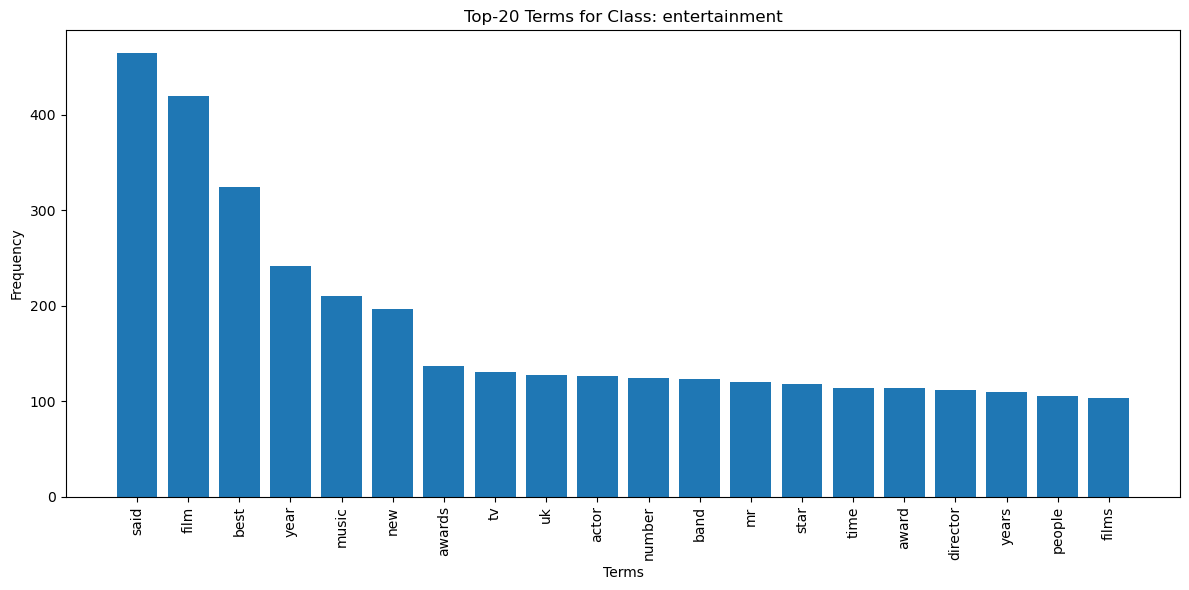

In [ ]:

# (ii) Term Frequency Distribution Per Class


classes = train_df[LABEL_COLUMN].unique()

for cls in classes:
    
    class_subset = train_df[train_df[LABEL_COLUMN] == cls]
    
    X_class = vectorizer.transform(class_subset[TEXT_COLUMN])
    
    class_term_freq = np.array(X_class.sum(axis=0)).flatten()
    
    class_freq_df = pd.DataFrame({
        'term': feature_names,
        'frequency': class_term_freq
    })
    
    top20_class = class_freq_df.sort_values(
        by='frequency',
        ascending=False
    ).head(20)
    
    plt.figure(figsize=(12, 6))
    plt.bar(top20_class['term'], top20_class['frequency'])
    plt.xticks(rotation=90)
    plt.title(f"Top-20 Terms for Class: {cls}")
    plt.xlabel("Terms")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

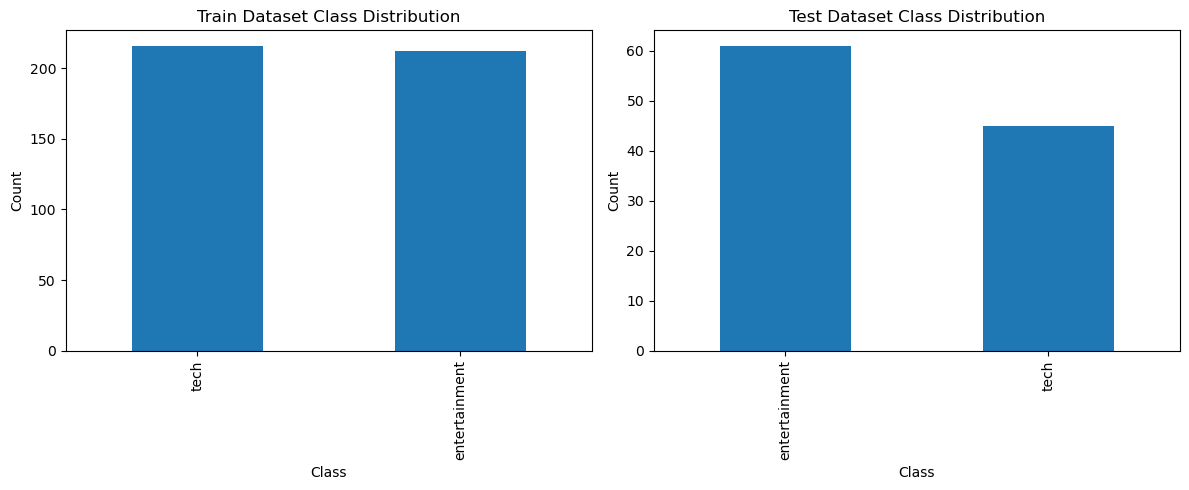

In [ ]:

# (iii) Class Distribution for Train and Test


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train distribution
train_df[LABEL_COLUMN].value_counts().plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title("Train Dataset Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

# Test distribution
test_df[LABEL_COLUMN].value_counts().plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title("Test Dataset Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()